# Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import correlate
from scipy.interpolate import interp1d
from hapi import *
from pylab import plot
import pickle
from scipy.stats import chi2
from scipy.stats import norm
import matplotlib.ticker as ticker
from pathlib import Path
import gc
from concurrent.futures import ProcessPoolExecutor, as_completed


# from bin_spec import bin_spectrum
import seaborn as sns

%matplotlib widget


In [6]:
os.chdir('/Users/zaniaccollins/Research/SGL/sgl_science_case')

In [13]:
os.getcwd()

'/Users/zaniaccollins/Research/SGL/sgl_science_case'

In [16]:
data_path = '/Users/zaniaccollins/Research/SGL/sgl_science_case/data/xsc_spectra'
# spectra_dict_path = f'{data_path}spectra_dict_cache_dwn1e-4_earth/'

# Helper functions

In [84]:
def get_molecule_id(molecule_name):
    """Return (M, common_local_I) for a molecule by name"""
    for (M, I), data in hapi.ISO.items():
        if data[4].upper() == molecule_name.upper():   # data[4] is the molecule name like 'N2O'
            return M, I   # returns first (main) isotopologue
    raise ValueError(f"Molecule {molecule_name} not found in hapi.ISO")

def cross_correlate_spectra(template_spectra, test_spectra, lags=None, return_full=True):
    """
    Perform zero-mean normalized cross-correlation between two spectra.
    Returns a dictionary with all relevant results.
    """
    # Zero-mean normalization
    template_norm = (template_spectra - np.mean(template_spectra)) / np.std(template_spectra)
    test_norm     = (test_spectra     - np.mean(test_spectra))     / np.std(test_spectra)
    
    # Cross-correlation
    ccf = correlate(template_norm, test_norm, mode='full')
    ccf /= np.sqrt(np.sum(template_norm**2) * np.sum(test_norm**2))
    
    # Lags
    if lags is None:
        lags = np.arange(-len(template_norm) + 1, len(template_norm))
    
    # Basic statistics
    max_corr = np.max(ccf)
    peak_idx = np.argmax(ccf)
    
    # Noise estimation from wings (excluding central peak)
    window_size = int(0.15 * len(ccf))
    noise_mask = np.ones(len(ccf), dtype=bool)
    noise_mask[max(0, peak_idx - window_size): min(len(ccf), peak_idx + window_size)] = False
    noise_values = ccf[noise_mask]
    noise_std = np.std(noise_values) if len(noise_values) > 20 else np.std(ccf)
    
    # SNR array
    cc_snr = ccf / noise_std if noise_std > 0 else np.zeros_like(ccf)
    
    results = {
        'ccf': ccf,
        'lags': lags,
        'max_correlation': max_corr,
        'peak_lag': lags[peak_idx],
        'noise_std': noise_std,
        'template_norm': template_norm,
        'test_norm': test_norm,
    }
    
    if return_full:
        results['ccf_clean'] = np.clip(np.nan_to_num(ccf, nan=0.0), 0, None)
    
    return results

def compute_log_likelihood(template, test):
    """
    Continuum-subtracted Gaussian log-likelihood (up to an additive constant).
    Model: test ≈ a * template + noise
    logL = -N/2 * log(mean residual^2)
    """
    f = np.asarray(template, dtype=float)
    g = np.asarray(test, dtype=float)

    f = f - np.mean(f)
    g = g - np.mean(g)

    N = f.size
    denom = np.dot(f, f)

    if denom <= 0 or N < 2:
        return -np.inf, 0.0

    # optimal scale: data ≈ a * model
    a = np.dot(f, g) / denom

    residual = g - a * f
    sigma2 = np.dot(residual, residual) / N

    # floor relative to data power (avoids log(0) without a fixed 1e-10 cliff)
    floor = 1e-30 * (np.dot(g, g) / N + 1e-30)
    sigma2 = max(sigma2, floor)

    logL = -0.5 * N * np.log(sigma2)
    return logL, a

def load_scenario(scenario_key, out_dir=None):

    path = os.path.join(out_dir, f"{scenario_key}.pkl")
    with open(path, "rb") as f:
        return pickle.load(f)

def cross_correlate_two_templates(template_A, template_B, test_scenario, in_dir = data_path):
    """
    Cross-correlate two specific clean templates against the noisy versions
    of a single test scenario.
    """  

    print(f"Loading scenarios...")
    data_A = load_scenario(template_A, in_dir)
    data_B = load_scenario(template_B, in_dir)
    data_test = load_scenario(test_scenario, in_dir)

    # Only use resolutions that exist in all three
    common_resolutions = sorted(
        set(data_A.keys()) & set(data_B.keys()) & set(data_test.keys())
    )
    print('Common resolutions: ', common_resolutions)

    records = []

    for r in common_resolutions:
        # Check that everything we need exists
        template_A_spec = data_A[r]['xsec_clean'][1:-1] # avoid nans; artifact of binning
        template_B_spec = data_B[r]['xsec_clean'][1:-1]

        # Loop over noisy versions of the test scenario at this resolution
        for key in data_test[r]:
            if not key.startswith('xsec_snr'):
                continue

            noisy_spec = data_test[r][key][1:-1] #avoid nans; artifact of binning
            snr_value = int(key.split('snr')[-1])

            print(f'Cross correlating at R = {r}, snr = {snr_value}')

            if len(template_A_spec) != len(noisy_spec):
                continue

            # Log-likelihoods
            log_lik_A, _ = compute_log_likelihood(template_A_spec, noisy_spec)
            log_lik_B, _ = compute_log_likelihood(template_B_spec, noisy_spec)

            delta_ll = log_lik_B - log_lik_A
            delta_ll /= len(template_A_spec)

            ts = 2.0 * delta_ll
            p = chi2.sf(ts, df=1)
            print(p)
            # p = max(float(p), 1e-300)          # avoid isf(0) → inf
            sigma = (norm.isf(p / 2.0))
            # sigma = min(sigma, 50.0)            # display cap

            print(
                f"R={r} SNR={snr_value}  "
                f"logL_A={log_lik_A:.6e}  logL_B={log_lik_B:.6e}  "
                f"delta={delta_ll:.6e}  sigma={sigma}"
            )

            if r == 1e7:
                print('----------------------------------')
                print(f"  log_lik_A = {log_lik_A:.3f}")
                print(f"  log_lik_B = {log_lik_B:.3f}")
                print(f"  delta    = {log_lik_B - log_lik_A:.3f}")

            # delta_ll = log_lik_B - log_lik_A
            # ts = 2 * delta_ll
            # p = chi2.sf(ts, df=1)
            # sigma = norm.isf(p / 2.0)

            print(f'sigma = {sigma}')

            records.append({
                'resolution': r,
                'snr': snr_value,
                'delta_logL': delta_ll,
                'sigma': sigma,
            })

            del noisy_spec
            gc.collect()

        del template_A_spec, template_B_spec
        gc.collect()

    # Free memory
    del data_A, data_B, data_test
    gc.collect()

    df = pd.DataFrame(records)
    print(f"Generated {len(df)} records for {template_A} vs {template_B}")
    return df
    
def cross_correlate_spectra_in_dict(parent_dict, lags=None, return_full=True):
    """
    Perform zero-mean normalized cross-correlation for all scenarios in input spectral dictionary
    
    Returns a dictionary with all relevant results.
    """

    records = []

    for r, res_data in parent_dict.items():
        for scen_template in res_data:
            clean_key = 'xsec_clean'
            if clean_key not in res_data[scen_template]:
                continue

            template_spectra = res_data[scen_template][clean_key]

            for scen_test in res_data:
                for key in list(res_data[scen_test].keys()):
                    if not key.startswith('xsec_snr'):
                        continue

                    noisy_spectra = res_data[scen_test][key]
                    snr_value = key.split('snr')[-1]

                    if len(template_spectra) != len(noisy_spectra):
                        continue

                    results = cross_correlate_spectra(template_spectra, noisy_spectra)

                    # Compute the log likelihood
                    log_lik, _ = compute_log_likelihood(template_spectra, noisy_spectra)

                    if not np.isfinite(delta_ll):
                        # One or both models matched the data to machine precision
                        sigma = np.inf if delta_ll > 0 else 0.0
                    else:
                        # Likelihood-ratio test, 1 extra degree of freedom
                        ts = 2.0 * delta_ll
                        p = chi2.sf(ts, df=1)
                        sigma = norm.isf(p / 2.0) if p > 0 else np.inf

                    records.append({
                        'resolution': r,
                        'template_scenario': scen_template,
                        'test_scenario': scen_test,
                        'snr': int(snr_value),
                        'max_correlation': results['max_correlation'],
                        'peak_lag': results['peak_lag'],
                        'noise_std': results['noise_std'],
                        # 'ccf': results['ccf'],
                        # 'lags': results['lags'],
                        'log_lik': log_lik
                    })
    df = pd.DataFrame(records)
    print(f"Generated {len(df)} cross-correlation records")
    return df



# Spectra

In [29]:

res_dict = {}

file_a = f'ALL_SULFUR_NO_DMS.pkl'
file_b = f'ALL_SULFUR_WITH_DMS.pkl'


with open(f'{data_path}/{file_a}', 'rb') as f:
    res_dict[f'no_dms'] = pickle.load(f)

with open(f'{data_path}/{file_a}', 'rb') as f:
    res_dict[f'with_dms'] = pickle.load(f)



# for sce in scenarios:
#     # Create a nice scenario key (e.g. 'H2O', 'CH4+N2O')
#     if len(sce) == 1:
#         scenario_key = sce[0][0]
#         isotope = sce[0][1]
#     else:
#         scenario_key = '+'.join([mol for mol, iso in sce])    

#     print(f'initialized res_dict{scenario_key}')
#     file = f'{scenario_key}.pkl'

#     with open(f'{data_path}/{file}', 'rb') as f:
#         res_dict[f'{scenario_key}'] = pickle.load(f)
        

In [24]:
res_dict['DMDS+CS2+SF6'][1000].keys()

dict_keys(['wavelength_grid', 'xsec_clean', 'resolution', 'xsec_snr5', 'error_snr5', 'xsec_snr10', 'error_snr10', 'xsec_snr25', 'error_snr25', 'xsec_snr50', 'error_snr50'])

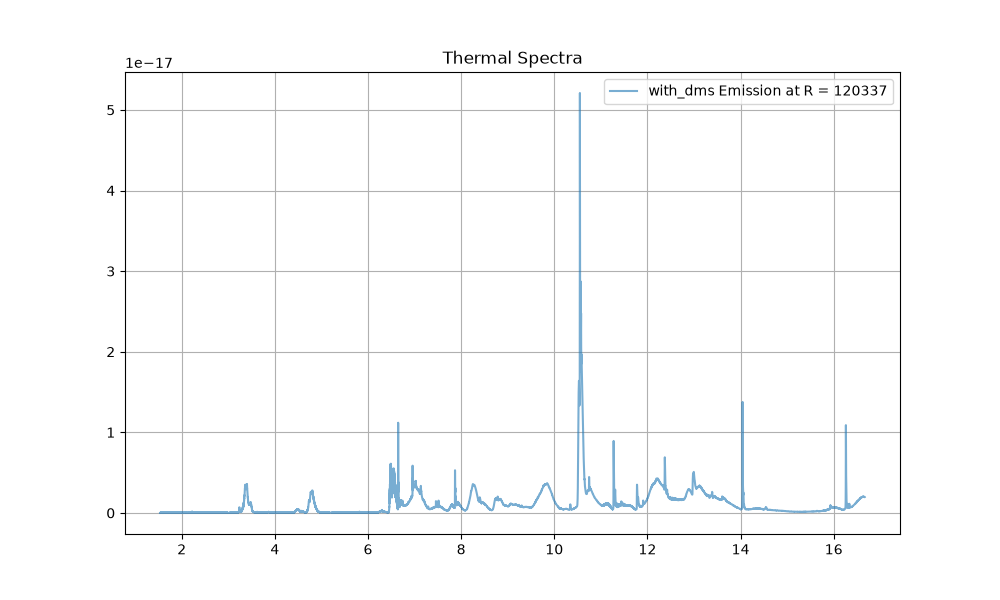

In [ ]:
resolution_to_plot = 120337
scenario_to_plot = 'with_dms'
snr_to_plot_a = 10
snr_to_plot_b = 50

R_bin = 1e3

data = res_dict[scenario_to_plot][resolution_to_plot]
x = data['wavelength_grid']
# y = data['xsec_clean'] / np.median(data['xsec_clean'])
y = data['xsec_snr10']# / np.median(data['xsec_snr10'])



plt.figure(figsize=(10,6))

plt.plot(x,y, label = f'{scenario_to_plot} Emission at R = {resolution_to_plot}', alpha = 0.6)
plt.title('Thermal Spectra')
plt.grid()
plt.legend()
plt.show()

# Results

In [85]:
# plt.close('all')
template_A = 'ALL_SULFUR_NO_DMS'
template_B = 'ALL_SULFUR_WITH_DMS' 
test_scen = 'ALL_SULFUR_WITH_DMS'
df_cc = cross_correlate_two_templates(template_A, template_B, test_scenario=test_scen)


Loading scenarios...
Common resolutions:  [1000, 10000, 25000, 50000, 120337]
Cross correlating at R = 1000, snr = 5
0.4306117043217168
R=1000 SNR=5  logL_A=1.072549e+05  logL_B=1.079944e+05  delta=3.105865e-01  sigma=0.7881453275629776
sigma = 0.7881453275629776
Cross correlating at R = 1000, snr = 10
0.2248251323099644
R=1000 SNR=10  logL_A=1.078909e+05  logL_B=1.096448e+05  delta=7.366520e-01  sigma=1.2137973139046125
sigma = 1.2137973139046125
Cross correlating at R = 1000, snr = 25
0.07934754356704352
R=1000 SNR=25  logL_A=1.081619e+05  logL_B=1.118265e+05  delta=1.539108e+00  sigma=1.754484382977069
sigma = 1.754484382977069
Cross correlating at R = 1000, snr = 50
0.03542563841715429
R=1000 SNR=50  logL_A=1.082095e+05  logL_B=1.134769e+05  delta=2.212271e+00  sigma=2.1034593120157834
sigma = 2.1034593120157834
Cross correlating at R = 1000, snr = 100
0.016031959364293222
R=1000 SNR=100  logL_A=1.082231e+05  logL_B=1.151273e+05  delta=2.899683e+00  sigma=2.4081871706161544
sigma =

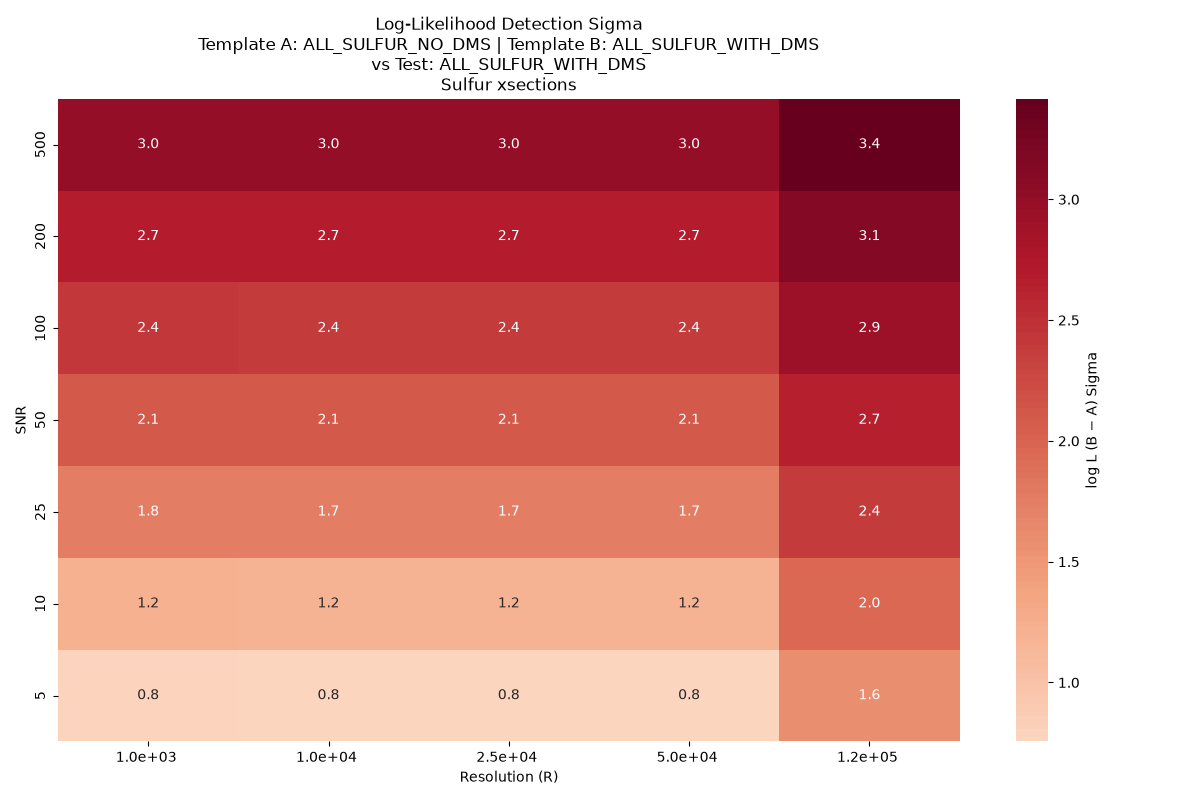

In [86]:
# merged = pd.merge(df_A, df_B, on=['resolution', 'snr'], suffixes=('_A', '_B'))

# Use log-likelihood difference (A - B)
# merged['delta_logL'] = merged['log_lik_B'] - merged['log_lik_A']

# Optional: compute significance (how many sigma the difference is)
# merged['delta_significance'] = merged['delta_logL'] / np.sqrt(merged['noise_std_A']**2 + merged['noise_std_B']**2)

# ======================
# Pivot for heatmap
# ======================
pivot = df_cc.pivot_table(
    index='snr', 
    columns='resolution', 
    values='sigma',        # or 'delta_significance'
    aggfunc='mean'
).sort_index(ascending=False)   # SNR increasing upwards

# ======================
# Annotation
# ======================
annot = pivot.copy().astype(str)

for i, snr in enumerate(pivot.index):
    for j, res in enumerate(pivot.columns):
        val = pivot.iloc[i, j]
        annot.iloc[i, j] = f"{val:.1f}"

# ======================
# Plot
# ======================
plt.figure(figsize=(12, 8))

ax=sns.heatmap(
    pivot,
    cmap='RdBu_r',           
    center=0,
    annot=annot,
    fmt='', 
    cbar_kws={'label': 'log L (B − A) Sigma'}
)



xticklabels = [f"{r:.1e} "
               for r in pivot.columns]
ax.set_xticklabels(xticklabels)

plt.xlabel('Resolution (R)')
plt.ylabel('SNR')
plt.title(
    f'Log-Likelihood Detection Sigma\n'
    f'Template A: {template_A} | Template B: {template_B}\n'
    f'vs Test: {test_scen}\n'
    'Sulfur xsections'
)

plt.tight_layout()
plt.show()